<a href="https://colab.research.google.com/github/PankajKumar17/bajpai/blob/main/Health_Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Health Insurance Cross Sell Prediction

**Predict Health Insurance Owners' who will be interested in Vehicle Insurance**

Your client is an Insurance company that has provided Health Insurance to its customers now they need your help in building a model to predict whether the customers from past year will also be interested in Vehicle Insurance provided by the company.

**Objective**

Building a model to predict whether a customer would be interested in Vehicle Insurance is extremely helpful for the company because it can then accordingly plan its communication strategy to reach out to those customers and optimise its business model and revenue.

# 1. Prepare the problem

### Importing  Required Libreries

In [59]:
import pandas as pd  # Data manipulation and analysis
import numpy as np  # Numerical computing
import seaborn as sns  # Data visualization
import matplotlib.pyplot as plt  # Plotting library
from sklearn.preprocessing import LabelEncoder  # Encode labels with value between 0 and n_classes-1
from sklearn.model_selection import train_test_split  # Split arrays or matrices into random train and test subsets

from imblearn.over_sampling import RandomOverSampler  # Class to perform over-sampling using random samples
from collections import Counter  # Dict subclass for counting hashable objects
from sklearn.preprocessing import StandardScaler  # Standardize features by removing the mean and scaling to unit variance
from sklearn.linear_model import LogisticRegression  # Logistic Regression classifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix, roc_auc_score, classification_report  # Evaluation metrics
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier
from xgboost import XGBClassifier  # Gradient boosting trees classifier

sns.set_theme(style="darkgrid")  # Set the visual theme for seaborn plots

### Load dataset

In [60]:
!pip install gdown  # Install gdown utility to download files from Google Drive

import gdown  # Library to download from Google Drive
import pandas as pd  # Dataframe library

file_id = '1tVht_H5niiNTHSOJKC8EJaMSi0VVWI8l'  # ID for the health insurance dataset file
output_filename = 'health_insurance.csv'  # Local filename for the downloaded data

gdown.download(id=file_id, output=output_filename, quiet=False)  # Execute download process

data = pd.read_csv(output_filename)  # Load the CSV data into a pandas DataFrame

Downloading...
From: https://drive.google.com/uc?id=1tVht_H5niiNTHSOJKC8EJaMSi0VVWI8l
To: /content/health_insurance.csv
100%|██████████| 21.4M/21.4M [00:00<00:00, 172MB/s]


# 2. Summarize Data

In [61]:
data.head()  # Display the first five rows of the dataset

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [62]:
data.tail()  # Display the last five rows of the dataset

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
381104,381105,Male,74,1,26.0,1,1-2 Year,No,30170.0,26.0,88,0
381105,381106,Male,30,1,37.0,1,< 1 Year,No,40016.0,152.0,131,0
381106,381107,Male,21,1,30.0,1,< 1 Year,No,35118.0,160.0,161,0
381107,381108,Female,68,1,14.0,0,> 2 Years,Yes,44617.0,124.0,74,0
381108,381109,Male,46,1,29.0,0,1-2 Year,No,41777.0,26.0,237,0


In [63]:
print(data.info())  # Summary of the DataFrame including index, columns, and data types
print()  # Print a blank line
print(data.isna().sum())  # Count and print null values for each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB
None

id                      0
Gender                  0
Age                     0
Driving_Licens

**Dataset has 381109 rows and 12 columns.**
**There is no missing values present in dataset.**


### Descriptive statistics

In [64]:
data.describe()  # Generate descriptive statistics for numeric columns

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


### Data visualizations

##### Target Variable

<Axes: xlabel='Response', ylabel='count'>

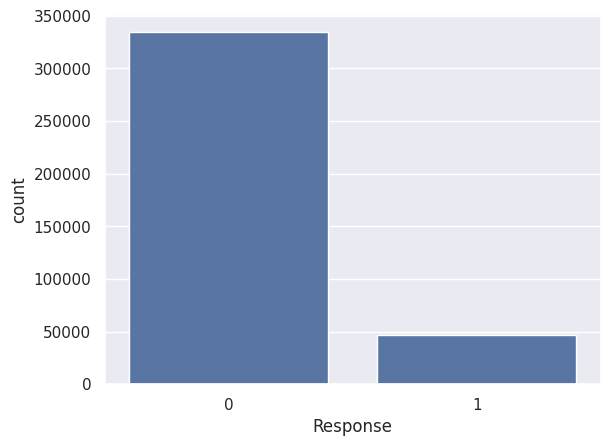

In [65]:
sns.set_theme(style="darkgrid")  # Apply darkgrid style for visualizations
sns.countplot(x='Response', data=data)  # Plot frequency distribution of the target 'Response' variable

* The data is highly imbalanced.

##### Gender

/tmp/ipykernel_3062/2118259707.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=data, palette='husl')  # Count plot for Gender distribution


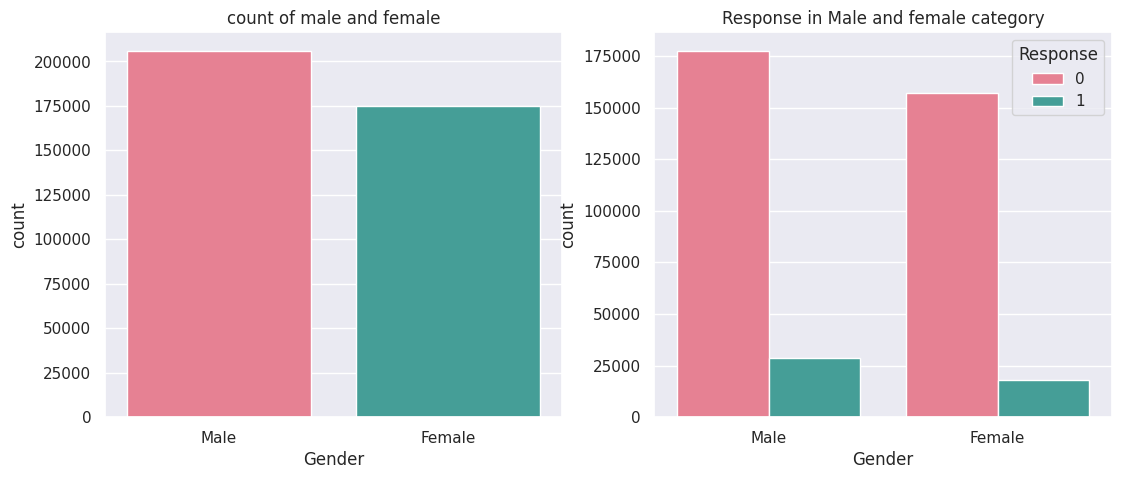

In [66]:
plt.figure(figsize = (13,5))  # Set the total figure width and height
plt.subplot(1,2,1)  # Create the first subplot in a 1x2 grid
sns.countplot(x='Gender', data=data, palette='husl')  # Count plot for Gender distribution
plt.title("count of male and female")  # Set title for the first plot
plt.subplot(1,2,2)  # Create the second subplot in a 1x2 grid
sns.countplot(x='Gender', hue='Response', data=data, palette="husl")  # Response distribution per Gender
plt.title("Response in Male and female category")  # Set title for the second plot
plt.show()  # Display both subplots

* The gender variable in the dataset is almost equally distributed.
* Male category is slightly greater than that of female and chances of buying the insurance is also little high.

##### Age Vs Response

<Axes: xlabel='Age', ylabel='count'>

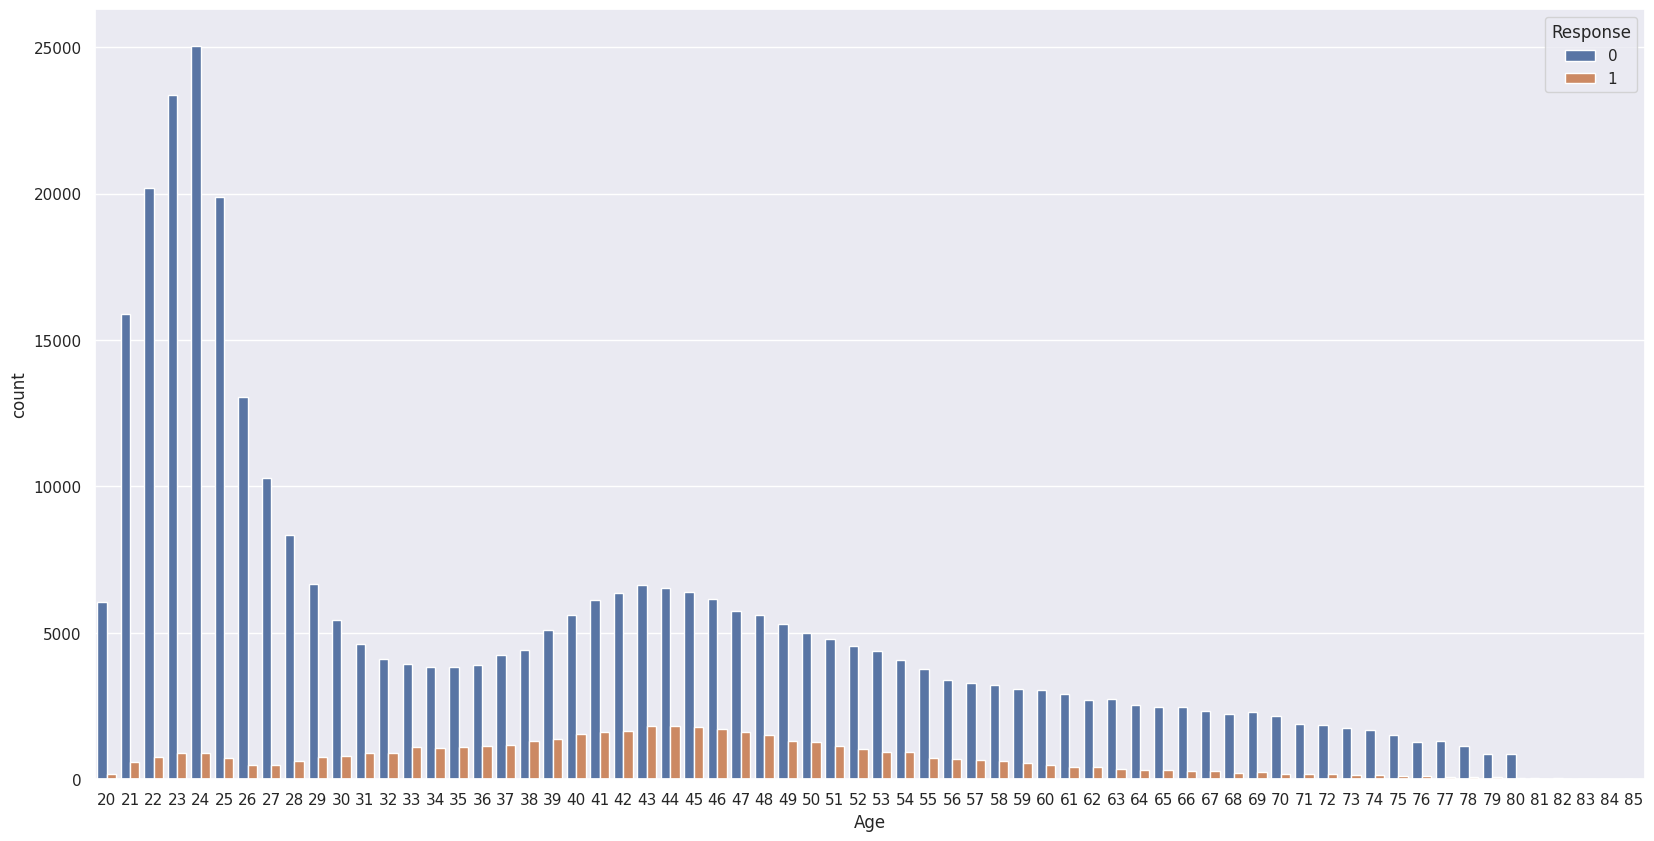

In [67]:
plt.figure(figsize=(20,10))  # Define large figure size for readability
sns.countplot(x='Age',hue='Response',data=data)  # Plot Age distribution split by target Response

<Axes: xlabel='Age'>

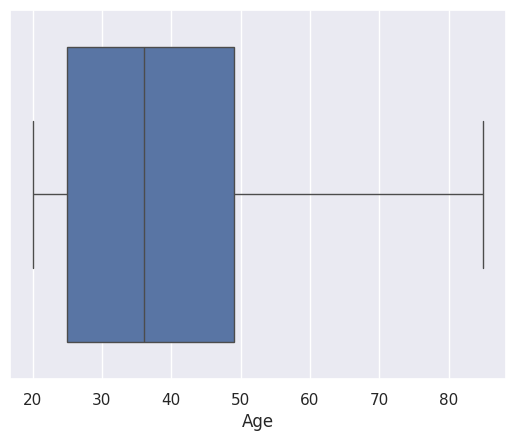

In [68]:
sns.boxplot(x=data['Age'])  # Create a boxplot to check for outliers in Age

* Young people below 30 are not interested in vehicle insurance. Reasons could be lack of experience, less maturity level and they don't have expensive vehicles yet.
* People aged between 30-60 are more likely to be interested.
* From the boxplot we can see that there no outlier in the data.

#### Driving License

In [ ]:
sns.countplot(x='Driving_License', hue='Response', data=data)  # Count of Response based on Driving License ownership

* Customers who are interested in Vehicle Insurance almost all have driving license

##### Previously_Insured Vs Response

<Axes: xlabel='Previously_Insured', ylabel='count'>

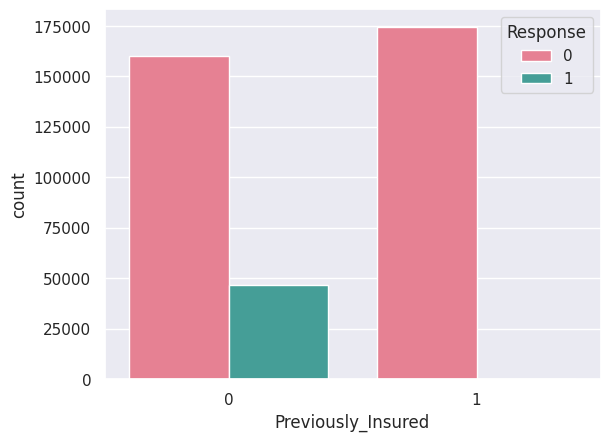

In [30]:
sns.countplot(x='Previously_Insured',hue='Response',data=data,palette='husl')  # Count of Response based on previous insurance history

* Customer who are not perviosly insured are likely to be inetrested

sns.countplot(x='Vehicle_Age',hue='Response',data=data,palette='husl')  # Count of Response based on age of the vehicle

<Axes: xlabel='Vehicle_Age', ylabel='count'>

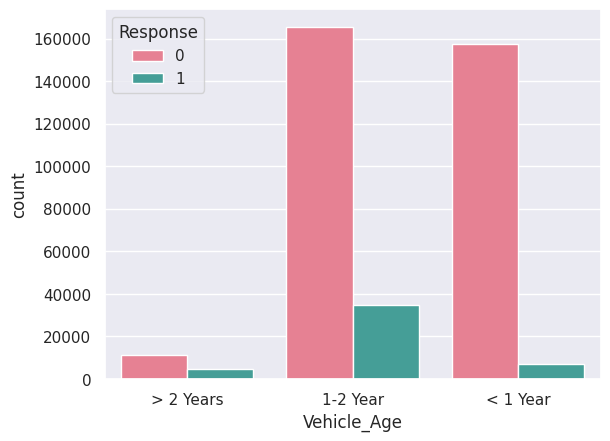

In [31]:
sns.countplot(x='Vehicle_Age',hue='Response',data=data,palette='husl')

* Customers with vechicle age 1-2 years are more likely to interested as compared to the other two

* Customers with with Vehicle_Age <1 years have very less chance of buying Insurance

##### Annual_Premium


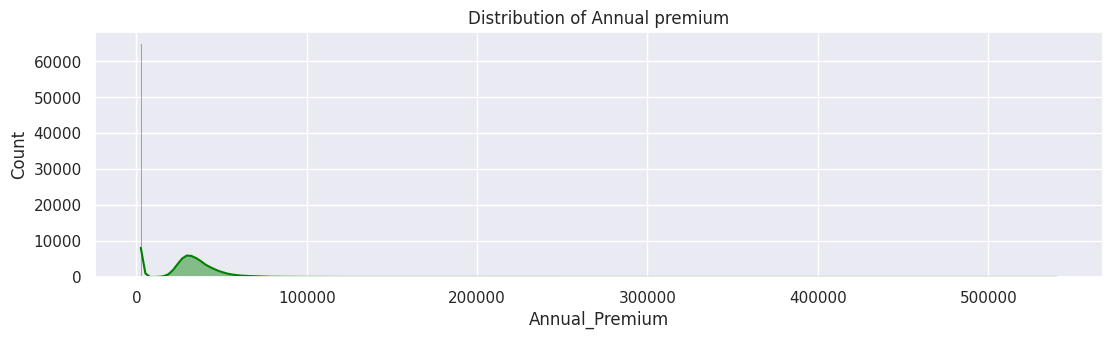

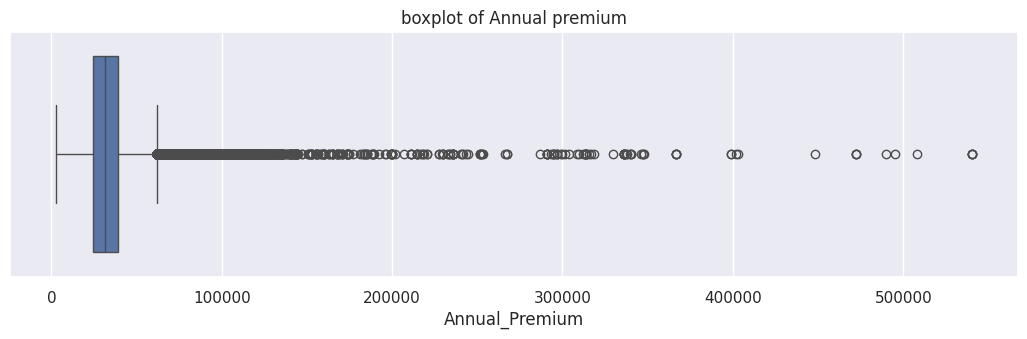

In [32]:
plt.figure(figsize=(13,7))  # Set figure size
plt.subplot(2,1,1)  # Define top subplot in a 2x1 grid
sns.histplot(data['Annual_Premium'], color='green', kde=True)  # Histogram with Kernel Density Estimate
plt.title("Distribution of Annual premium")  # Set top plot title
plt.show()  # Show the distribution plot
plt.figure(figsize=(13,7))  # Re-initialize figure for the next plot
plt.subplot(2,1,2)  # Define bottom subplot in a 2x1 grid
sns.boxplot(x=data['Annual_Premium'])  # Boxplot for Annual Premium
plt.title("boxplot of Annual premium")  # Set bottom plot title
plt.show()  # Show the boxplot


* From the distribution plot we can infer that the annual premimum variable is right skewed
* From the boxplot we can observe lot of outliers in the variable

##### Correlation Matrix

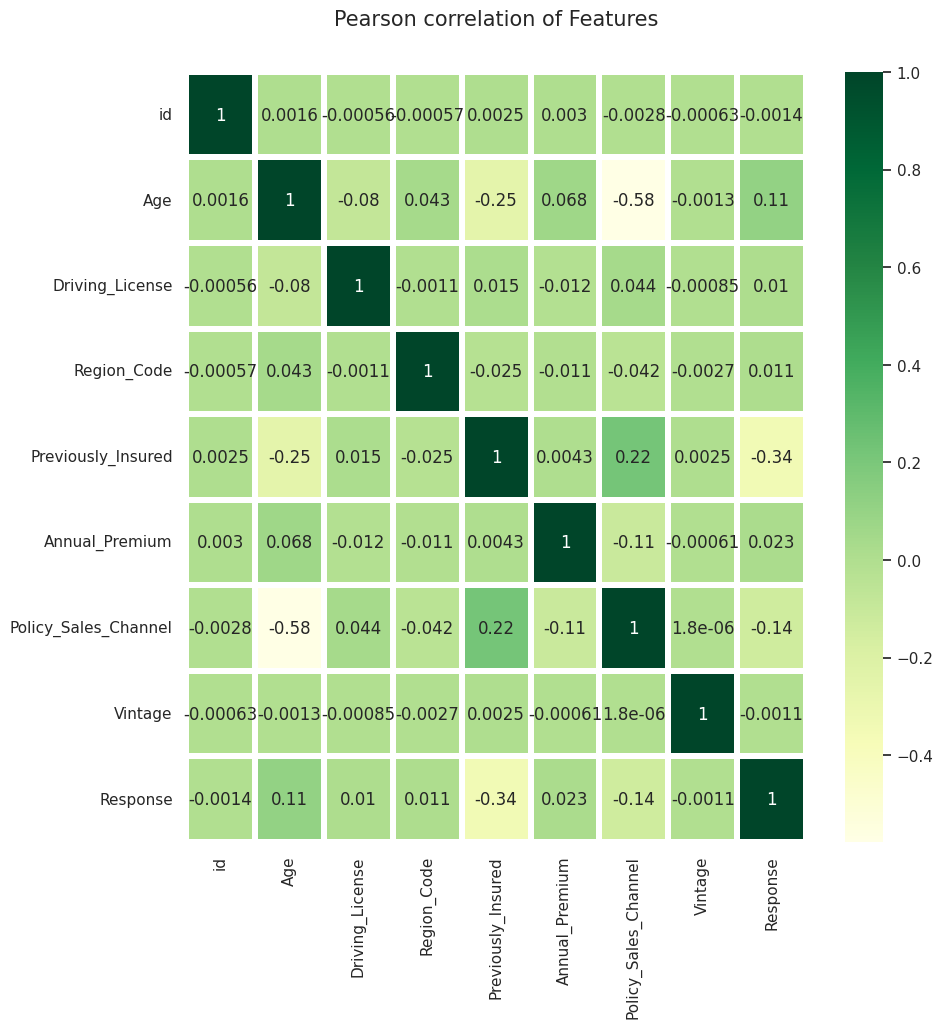

In [37]:
corr = data.corr(numeric_only=True)  # Calculate correlation matrix for numeric features only
f, ax = plt.subplots(figsize=(10,10))  # Create figure and axis for heatmap
sns.heatmap(corr, ax=ax, annot=True, linewidths=3, cmap='YlGn')  # Draw annotated heatmap
plt.title("Pearson correlation of Features", y=1.05, size=15)  # Set plot title with offset
plt.show()  # Display the heatmap

*  Target variable is not much affected by Vintage variable. we can drop least correlated variable.

# 3. Prepare Data

##### Label encoding

In [38]:
labelEncoder= LabelEncoder()  # Initialize LabelEncoder object
data['Gender'] = labelEncoder.fit_transform(data['Gender'])  # Convert Gender (Male/Female) to numeric labels
data['Vehicle_Age'] = labelEncoder.fit_transform(data['Vehicle_Age'])  # Convert Vehicle_Age categories to numeric
data['Vehicle_Damage'] = labelEncoder.fit_transform(data['Vehicle_Damage'])  # Convert Vehicle_Damage (Yes/No) to numeric

In [39]:
data.dtypes  # Check data types of all columns after encoding

,0
id,int64
Gender,int64
Age,int64
Driving_License,int64
Region_Code,float64
Previously_Insured,int64
Vehicle_Age,int64
Vehicle_Damage,int64
Annual_Premium,float64
Policy_Sales_Channel,float64


##### Checking duplicate rows

In [40]:
duplicate=data[data.duplicated()]  # Identify duplicate rows in the DataFrame
print(duplicate)  # Display any found duplicates

Empty DataFrame
Columns: [id, Gender, Age, Driving_License, Region_Code, Previously_Insured, Vehicle_Age, Vehicle_Damage, Annual_Premium, Policy_Sales_Channel, Vintage, Response]
Index: []


* there is no duplicated rows in the dataset

###### Seprating dependent and independent variables

In [41]:
x=data.drop(['Response'],axis=1)  # Select all columns except 'Response' as features
y=data['Response']  # Select 'Response' as the target label

#### Feature Selection

[0.19332373 0.0057558  0.13927779 0.0004882  0.09533207 0.05870957
 0.01580551 0.07265903 0.16333234 0.06821249 0.18710347]


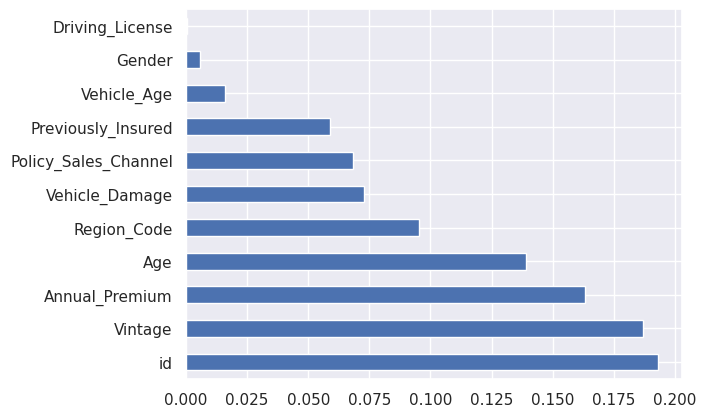

In [42]:
from sklearn.ensemble import ExtraTreesClassifier  # Import tree-based classifier for feature importance
model = ExtraTreesClassifier()  # Initialize the model
model.fit(x,y)  # Fit model to data to calculate feature importance
print(model.feature_importances_)  # Output the relative importance scores
feat_importances = pd.Series(model.feature_importances_, index=x.columns)  # Map scores to column names
feat_importances.nlargest(11).plot(kind='barh')  # Plot top 11 most important features as a horizontal bar chart
plt.show()  # Render the plot

* We can remove less important features from the data set

In [43]:
x=x.drop(['Driving_License','Gender'],axis=1)  # Drop least important features determined by the importance analysis

#### Handling Imbalanced data
*  When observation in one class is higher than the observation in other classes then there exists a class imbalance. We can clearly see that there is a huge difference between the data set. Solving this issue we use resampling technique.

Original dataset shape Counter({0: 334399, 1: 46710})
Resampled dataset shape Counter({1: 334399, 0: 334399})


/tmp/ipykernel_3062/99750634.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_new, palette='husl')


<Axes: xlabel='Response', ylabel='count'>

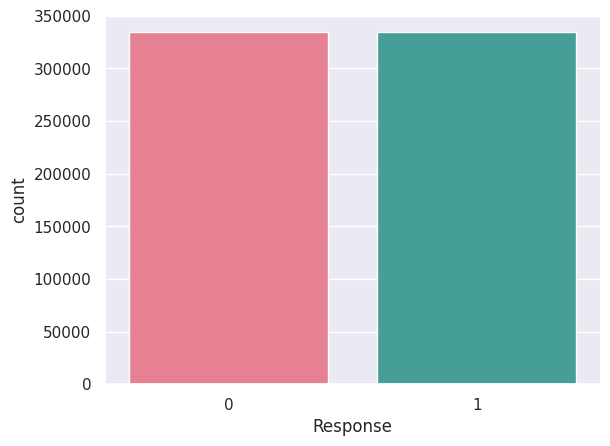

In [44]:
x = data.drop(['Response', 'Driving_License', 'Gender', 'id'], axis=1)  # Redefine features by dropping non-essential columns
y = data['Response']  # Ensure target variable is defined
randomsample = RandomOverSampler()  # Initialize sampler to balance the minority class
x_new, y_new = randomsample.fit_resample(x, y)  # Perform over-sampling to reach class parity
from collections import Counter  # Import counter
print('Original dataset shape {}'.format(Counter(y)))  # Display distribution before sampling
print('Resampled dataset shape {}'.format(Counter(y_new)))  # Display distribution after sampling
sns.countplot(x=y_new, palette='husl')  # Visualize the balanced target class

#### spliting of data into train and test data

In [45]:
xtrain,xtest,ytrain,ytest=train_test_split(x_new,y_new,test_size=.30,random_state=0)  # Split data: 70% training, 30% testing
print(xtrain.shape,xtest.shape,ytrain.shape,ytest.shape)  # Verify split dimensions
from sklearn.preprocessing import StandardScaler  # Import scaler
scaler=StandardScaler()  # Initialize standard scaler
xtrain=scaler.fit_transform(xtrain)  # Fit and transform training data to normalize features
xtest=scaler.transform(xtest)  # Transform test data using training parameters

(468158, 8) (200640, 8) (468158,) (200640,)


#4. Model Selection
* Problem can be identified as Binary Classification (wheather customer opts for vehicle insurance or not)

* Dataset has more than 300k records

* cannot go with SVM Classifier as it takes more time to train as dataset increase
* Idea is to start selection of models as:

       1.Logistic Regression

       2.Random Forest

       3.XGBClassifier

###  1.Logistic Regression





In [46]:
model=LogisticRegression()  # Initialize Logistic Regression model
model=model.fit(xtrain,ytrain)  # Train model on scaled training data
pred=model.predict(xtest)  # Predict binary outcomes for test data
lr_probability =model.predict_proba(xtest)[:,1]  # Get predicted probabilities for positive class
acc_lr=accuracy_score(ytest,pred)  # Calculate accuracy
recall_lr=recall_score(ytest,pred)  # Calculate recall
precision_lr=precision_score(ytest,pred)  # Calculate precision
f1score_lr=f1_score(ytest,pred)  # Calculate F1-score
AUC_LR=roc_auc_score(ytest, lr_probability)  # Calculate ROC AUC score
print("Accuracy : ", accuracy_score(ytest,pred))  # Print final accuracy
print("ROC_AUC Score:",AUC_LR)  # Print final AUC

Accuracy :  0.7839812599681021
ROC_AUC Score: 0.8343090162919764


In [47]:
print(classification_report(pred,ytest))  # Detailed breakdown of precision, recall, and f1 per class

              precision    recall  f1-score   support

           0       0.59      0.96      0.73     61402
           1       0.98      0.70      0.82    139238

    accuracy                           0.78    200640
   macro avg       0.78      0.83      0.78    200640
weighted avg       0.86      0.78      0.79    200640



### ROC Curve


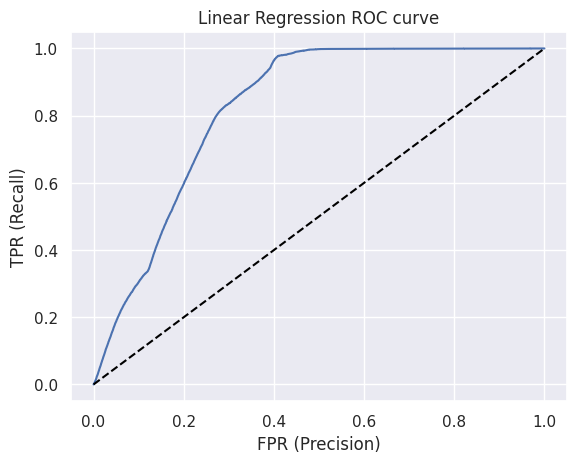

In [48]:
from sklearn.metrics import roc_curve  # Import roc_curve calculation
fpr, tpr, _ = roc_curve(ytest, lr_probability)  # Calculate false positive and true positive rates
plt.title('Linear Regression ROC curve')  # Set plot title
plt.xlabel('FPR (Precision)')  # Set X-axis label
plt.ylabel('TPR (Recall)')  # Set Y-axis label
plt.plot(fpr,tpr)  # Plot the ROC curve
plt.plot((0,1), ls='dashed',color='black')  # Draw baseline diagonal line
plt.show()  # Show plot

[[59194 41134]
 [ 2208 98104]]


<Axes: >

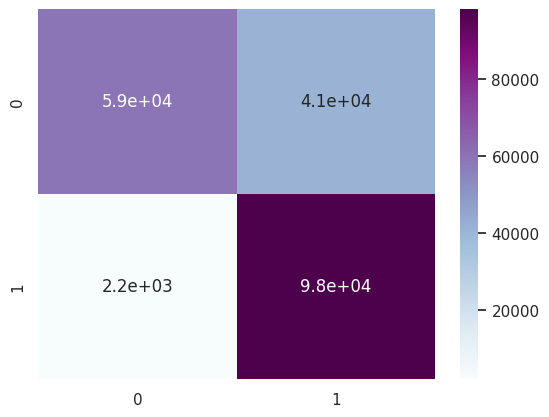

In [49]:
cm=confusion_matrix(ytest,pred)  # Create matrix for actual vs predicted labels
print(cm)  # Print matrix values
sns.heatmap(cm,annot=True,cmap='BuPu')  # Visualize confusion matrix as a heatmap

## 2.RandomForest Classifier

In [50]:
from sklearn.ensemble import RandomForestClassifier  # Import RF classifier
randomforest = RandomForestClassifier()  # Initialize model
randomforest=randomforest.fit(xtrain, ytrain)  # Train the model
y_pred = randomforest.predict(xtest)  # Predict test set labels
RF_probability = randomforest.predict_proba(xtest)[:,1]  # Predicted probabilities for ROC
AUC_RF=roc_auc_score(ytest, RF_probability)  # Calculate AUC
acc_rf=accuracy_score(ytest,y_pred)  # Calculate accuracy
recall_rf=recall_score(ytest,y_pred)  # Calculate recall
precision_rf=precision_score(ytest,y_pred)  # Calculate precision
f1score_rf=f1_score(ytest,y_pred)  # Calculate F1 score
print(accuracy_score(y_pred,ytest))  # Print overall accuracy
print("ROC_AUC Score:",AUC_RF)  # Print AUC score

0.9390151515151515
ROC_AUC Score: 0.9450946171272272


In [51]:
print(classification_report(y_pred,ytest))  # Report metrics for Random Forest

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     88600
           1       1.00      0.89      0.94    112040

    accuracy                           0.94    200640
   macro avg       0.94      0.95      0.94    200640
weighted avg       0.95      0.94      0.94    200640



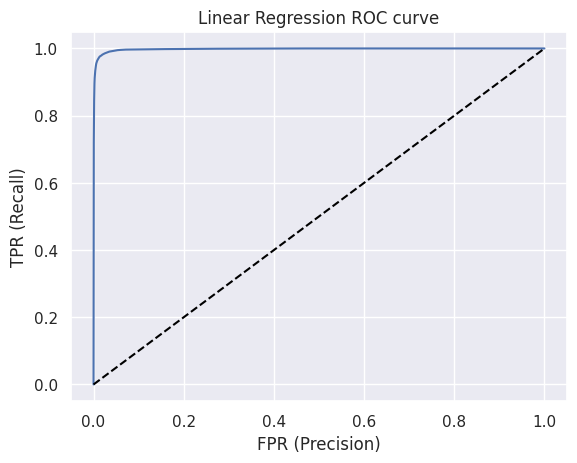

In [52]:
from sklearn.metrics import roc_curve  # Import tool
fpr, tpr, _ = roc_curve(ytest, RF_probability)  # Get curves values
plt.title('Random Forest ROC curve')  # Set title
plt.xlabel('FPR (Precision)')  # Label X
plt.ylabel('TPR (Recall)')  # Label Y
plt.plot(fpr,tpr)  # Plot curve
plt.plot((0,1), ls='dashed',color='black')  # Plot diagonal
plt.show()  # Display

[[ 88346    254]
 [ 11982 100058]]


<Axes: >

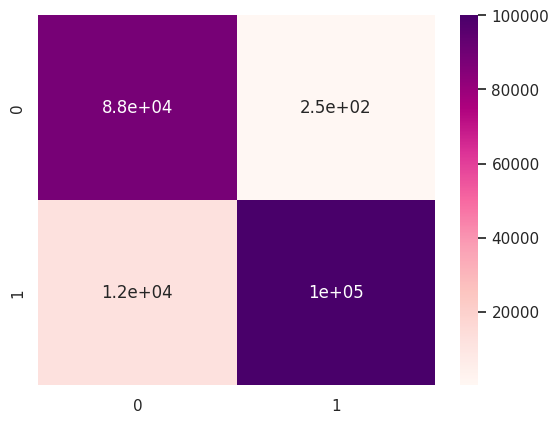

In [53]:
cm=confusion_matrix(y_pred,ytest)  # Create RF confusion matrix
print(cm)  # Print raw numbers
sns.heatmap(cm,annot=True,cmap='RdPu')  # Display heatmap of results

## 3. XGBClassifier

In [54]:
from xgboost import XGBClassifier  # Import XGBoost
xgb=XGBClassifier()  # Initialize model
XGB_fit=xgb.fit(xtrain, ytrain)  # Train model
y_predict = XGB_fit.predict(xtest)  # Generate predictions
XGB_probability = XGB_fit.predict_proba(xtest)[:,1]  # Generate probabilities
acc_xgb=accuracy_score(ytest,y_predict)  # Calc accuracy
recall_xgb=recall_score(ytest,y_predict)  # Calc recall
precision_xgb=precision_score(ytest,y_predict)  # Calc precision
f1score_xgb=f1_score(ytest,y_predict)  # Calc F1
AUC_xgb=roc_auc_score(ytest, XGB_probability)  # Calc AUC
print(accuracy_score(y_predict,ytest))  # Output accuracy
print("ROC_AUC Score:",AUC_xgb)  # Output AUC

0.8117075358851674
ROC_AUC Score: 0.8323733611508188


In [55]:
print(classification_report(y_predict,ytest))  # Show classification report for XGBoost

              precision    recall  f1-score   support

           0       0.69      0.92      0.78     75311
           1       0.94      0.75      0.83    125329

    accuracy                           0.81    200640
   macro avg       0.81      0.83      0.81    200640
weighted avg       0.84      0.81      0.81    200640



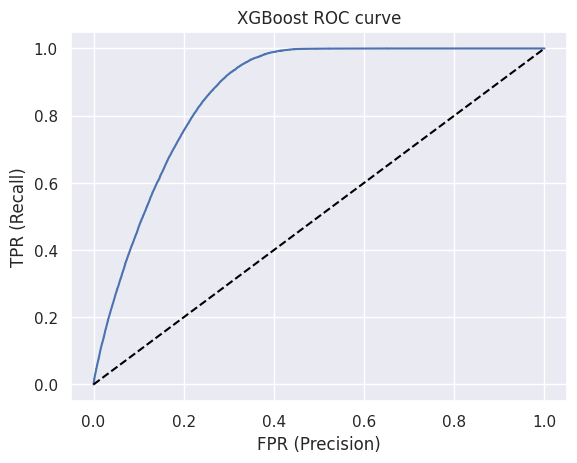

In [56]:
from sklearn.metrics import roc_curve  # Import utility
fpr, tpr, _ = roc_curve(ytest, XGB_probability)  # Get XGB curve data
plt.title('XGBoost ROC curve')  # Title
plt.xlabel('FPR (Precision)')  # X axis
plt.ylabel('TPR (Recall)')  # Y axis
plt.plot(fpr,tpr)  # Line plot
plt.plot((0,1), ls='dashed',color='black')  # Baseline
plt.show()  # Show

[[68930 31398]
 [ 6381 93931]]


<Axes: >

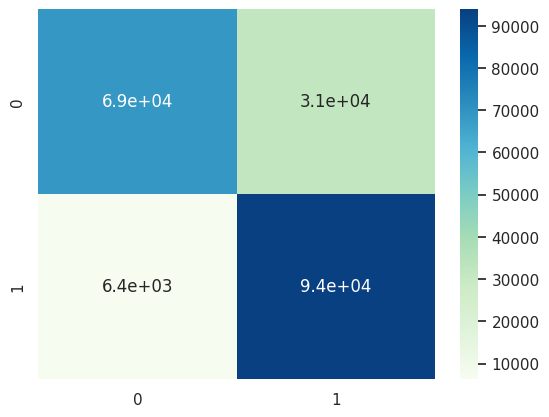

In [57]:
cm=confusion_matrix(ytest,y_predict)  # Confusion matrix for XGBoost
print(cm)  # Print matrix contents
sns.heatmap(cm,annot=True,cmap='GnBu')  # Plot results heatmap

## Comparing the model

In [58]:
ind=['Logistic regression','Randomforest','XGBClassifier']  # Model names for index
data={"Accuracy":[acc_lr,acc_rf,acc_xgb],"Recall":[recall_lr,recall_rf,recall_xgb],"Precision":[precision_lr,precision_rf,precision_xgb],
    'f1_score':[f1score_lr,f1score_rf,f1score_xgb],"ROC_AUC":[AUC_LR,AUC_RF,AUC_xgb]}  # Collection of calculated metrics
result=pd.DataFrame(data=data,index=ind)  # Create summary DataFrame
result  # Display the comparison table

,Accuracy,Recall,Precision,f1_score,ROC_AUC
Logistic regression,0.783981,0.977989,0.704578,0.819069,0.834309
Randomforest,0.939015,0.997468,0.893056,0.942379,0.945095
XGBClassifier,0.811708,0.936388,0.749475,0.832570,0.832373


The ML model for the problem statement was created using python with the help of the dataset, and the ML model created with Random Forest and XGBClassifier models performed better than Logistics Regression model. Thus, for the given problem, the models created by Random Forest and XGBClassifier.

# Conclusion

* Customers of age between 30 to 60 are more likely to buy insurance.
* Customers with Driving License have higher chance of buying Insurance.
* Customers with Vehicle_Damage are likely to buy insurance.
*  The variable such as Age, Previously_insured,Annual_premium  are more afecting the target variable.
* comparing ROC curve we can see that Random Forest model preform better. Because curves closer to the top-left corner, it indicate a better performance.
